## Homework 1: Gradient Descent

### Exercise 2: Backtracking Line Search


In [31]:
import numpy as np
import matplotlib.pyplot as plt

In [32]:
n_iters = 500
theta0_list = [-2, 0.5, 2]

# tolerance of gradient in GD (small values represents less distance from a stationary point)
tolL = .01

# tolerance of distance between current and next value of theta in GD
tol_theta = .01

In [ ]:
def L(theta):
    return theta ** 4 - 3 * (theta ** 2) + 2

def grad_L(theta):
    return 4 * (theta ** 3) - 6 * theta   

def backtracking(L, grad_L, theta, eta0=1.0, beta=0.5, c=1e-4):
    """
    Return a step size eta that satisfies the Armijo condition:
        L(theta - eta*g) <= L(theta) - c * eta * ||g||^2
    Inputs:
      - L:      R^n -> R
      - grad_L: R^n -> R^d
      - theta:  current point (np.ndarray)
      - eta0:   initial step size
      - beta:   shrinking factor in (0,1)
      - c:      Armijo constant in (0,1)
    """
    eta = eta0
    g = grad_L(theta)
    g_norm2 = np.dot(g, g)
    while L(theta - eta * g) > L(theta) - c * eta * g_norm2:
        eta *= beta
    return eta
    
def gradient_descent_backtracking(theta0, n_iters=500, eta0=1.0, beta=0.5, c=1e-4):
    thetas = [theta0]
    losses = [L(theta0)]
    etas = []

    theta = theta0
    theta_prev = theta0

    for _ in range(n_iters):
        g = grad_L(theta)

        # stopping criteria 1: small gradient
        if abs(g) < tolL:
            break

        eta = backtracking(L, grad_L, theta, eta0=eta0, beta=beta, c=c)
        etas.append(eta)

        # GD step
        theta = theta - eta * g

        thetas.append(theta)
        losses.append(L(theta))

        # stopping criteria 2: small parameter change
        if abs(theta - theta_prev) < tol_theta:
            break

        theta_prev = theta

    return theta, np.array(thetas), np.array(losses), np.array(etas)


In [34]:
def plot_loss_and_thetas(thetas, theta_star=None, domain=(-3, 3)):
    grid = np.linspace(domain[0], domain[1], 600)

    plt.figure(figsize=(7, 5))
    plt.plot(grid, L(grid), label="Loss")
    plt.scatter(thetas, L(thetas), alpha=0.7, label="successive thetas")
    plt.plot(thetas, L(thetas), alpha=0.5)

    if theta_star is not None:
        plt.scatter([theta_star], [L(theta_star)], color="red", zorder=5,
                    label=f"solution at {theta_star:.2f}")

    plt.title("Loss and Thetas")
    plt.xlabel("Theta")
    plt.ylabel("Loss value")
    plt.legend()
    plt.tight_layout()
    plt.show()


Θ = -2
theta last = 1.226872
L(theta0) = 6.000000, L(theta_last) = -0.249973
iterations = 7


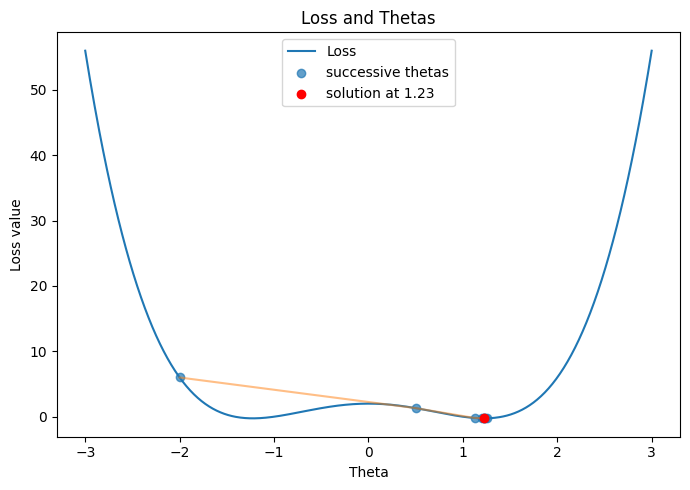


Θ = 0.5
theta last = 1.226872
L(theta0) = 1.312500, L(theta_last) = -0.249973
iterations = 6


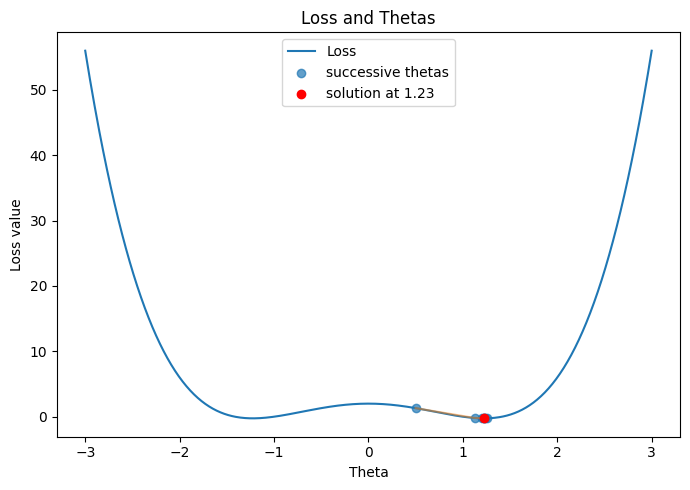


Θ = 2
theta last = -1.226872
L(theta0) = 6.000000, L(theta_last) = -0.249973
iterations = 7


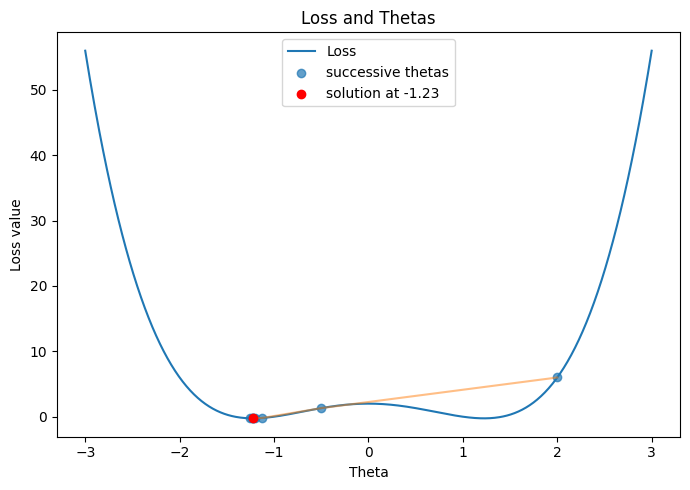

In [35]:
for theta0 in theta0_list:
    theta_last, thetas, losses, etas = gradient_descent_backtracking(
        theta0,
        n_iters=n_iters,
        eta0=1.0,   # initial guess for backtracking each iteration
        beta=0.5,   # shrink factor
        c=1e-4      # Armijo constant
    )

    print(f"\nΘ = {theta0}")
    print(f"theta last = {theta_last:.6f}")
    print(f"L(theta0) = {losses[0]:.6f}, L(theta_last) = {losses[-1]:.6f}")
    print(f"iterations = {len(thetas)-1}")

    plot_loss_and_thetas(thetas, theta_star=theta_last, domain=(-3, 3))

        
    plt.show()